Import libraries & load data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Data inspection

In [42]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)



Shape: (541909, 8)

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [43]:
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [44]:
print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Customers:", df["CustomerID"].nunique())




Duplicate Rows: 5268

Unique Customers: 4372


In [45]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Data cleaning

In [46]:
df = df.dropna(subset=["CustomerID"])
df = df.drop_duplicates()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (401604, 8)


In [47]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print("Shape after transaction filtering:", df.shape)

Shape after transaction filtering: (392692, 8)


Create Total Amount

In [48]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


RFM Analysis

In [49]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

rfm.head()

rfm.describe()


Reference Date: 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


RFM visualisation

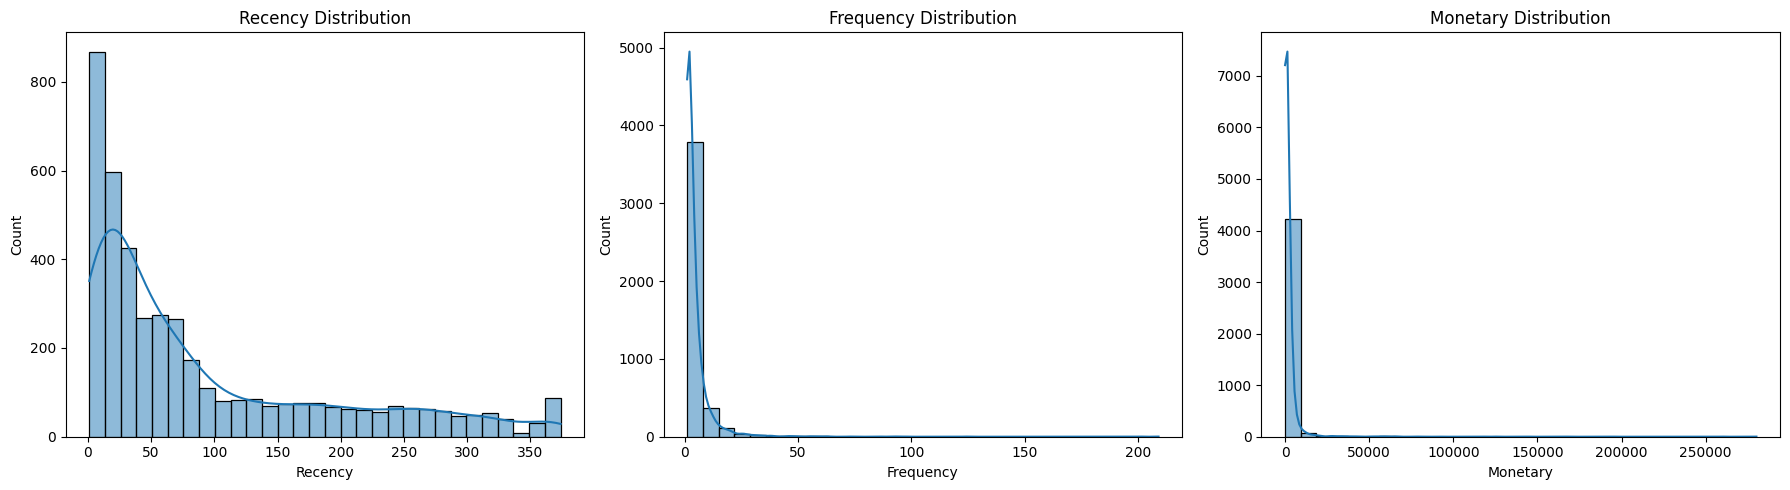

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

Prepare data for K-Means

Because RFM variables have very different scales, standardisation is needed before clustering. StandardScaler standardizes features by removing the mean and scaling to unit variance.

In [51]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


Elbow Method

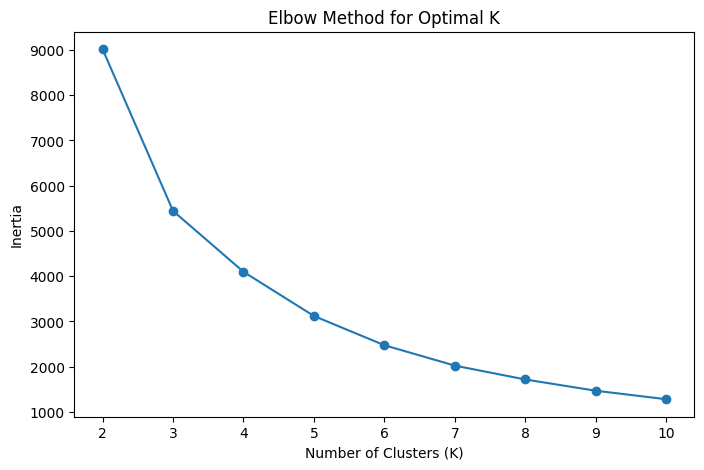

In [52]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

K-Means

For a strong customer segmentation project, I recommend starting with 4 clusters if your elbow plot supports it.

In [53]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

rfm["Cluster"].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


Cluster profiling

In [54]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile

cluster_profile.sort_values("Avg_Monetary", ascending=False)



,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85


Visualize the cluster profile


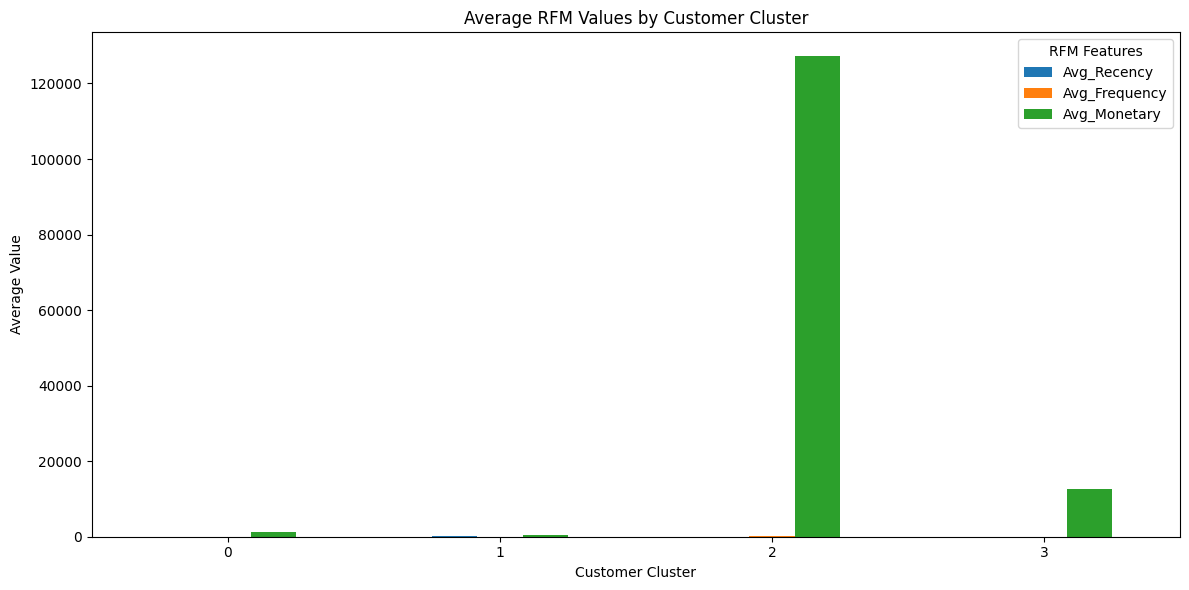

In [59]:
cluster_profile[["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average RFM Values by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="RFM Features")
plt.tight_layout()
plt.show()

RFM Chart

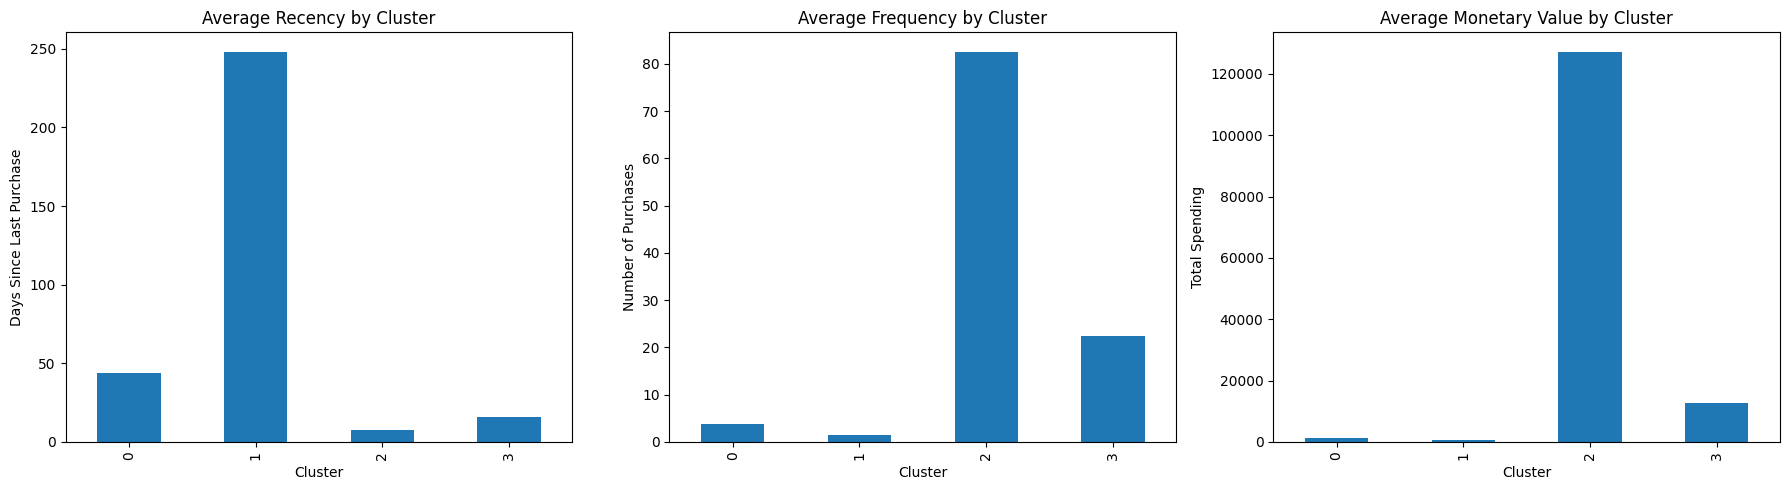

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_profile["Avg_Recency"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Average Recency by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Days Since Last Purchase")

cluster_profile["Avg_Frequency"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Average Frequency by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of Purchases")

cluster_profile["Avg_Monetary"].plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Average Monetary Value by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Total Spending")

plt.tight_layout()
plt.show()

## Cluster Profiling

The customer clusters were profiled using the average Recency, Frequency, and Monetary values along with the number of customers in each cluster.

- **Cluster 2** contains a small number of customers with very recent purchases, extremely high purchase frequency, and very high monetary value. These customers represent the highest-value customer group.
- **Cluster 3** consists of customers with recent purchases, relatively high purchase frequency, and high monetary value, indicating strong customer engagement.
- **Cluster 0** is the largest customer group. These customers show moderate recency, lower purchase frequency, and moderate monetary value.
- **Cluster 1** has the highest recency and the lowest frequency and monetary values, indicating customers who may have become inactive.

Customer Segment Visualization

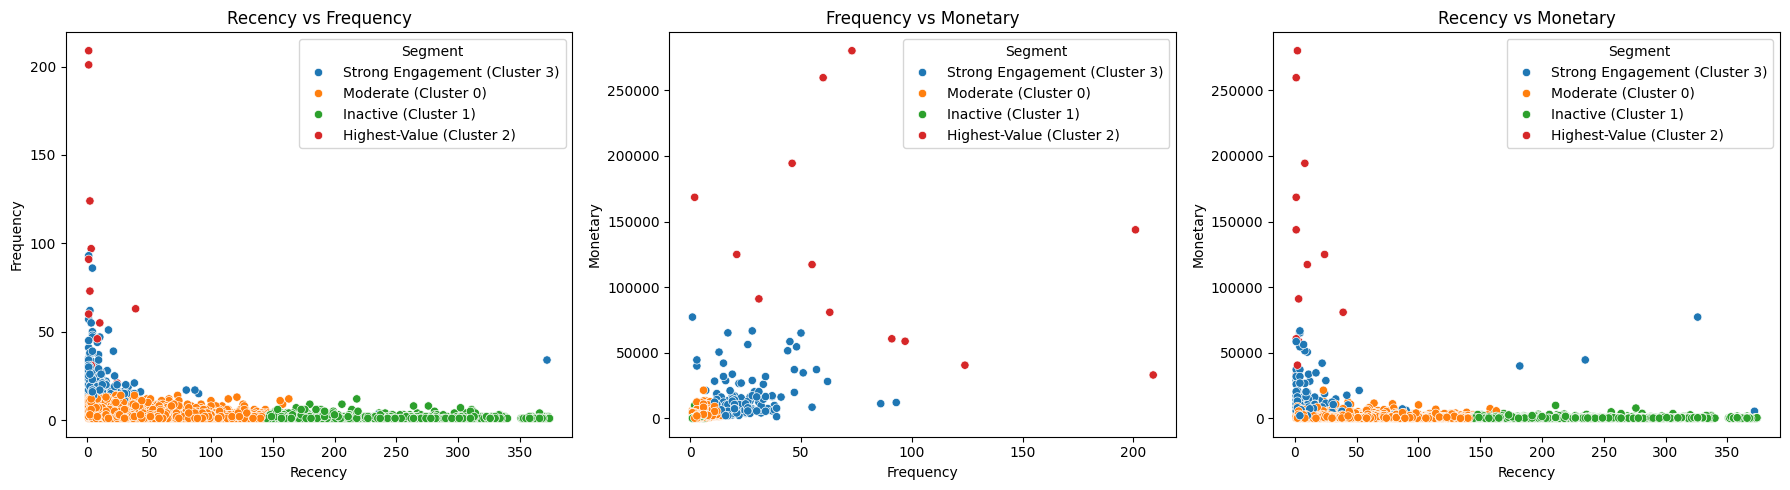

In [64]:
segment_names = {
    0: "Moderate (Cluster 0)",
    1: "Inactive (Cluster 1)",
    2: "Highest-Value (Cluster 2)",
    3: "Strong Engagement (Cluster 3)"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Segment",
    ax=axes[0]
)
axes[0].set_title("Recency vs Frequency")
axes[0].set_xlabel("Recency")
axes[0].set_ylabel("Frequency")

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    ax=axes[1]
)
axes[1].set_title("Frequency vs Monetary")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Monetary")

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    ax=axes[2]
)
axes[2].set_title("Recency vs Monetary")
axes[2].set_xlabel("Recency")
axes[2].set_ylabel("Monetary")

plt.tight_layout()
plt.show()

Customer Distribution by Segment

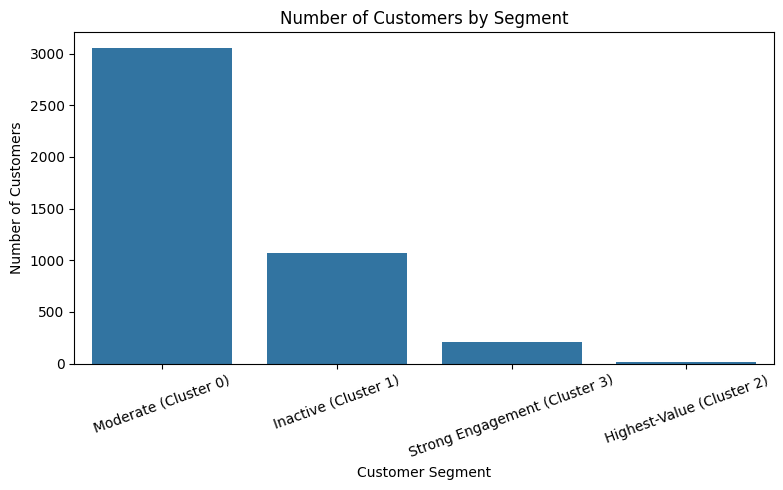

In [65]:


segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

RFM Heatmap

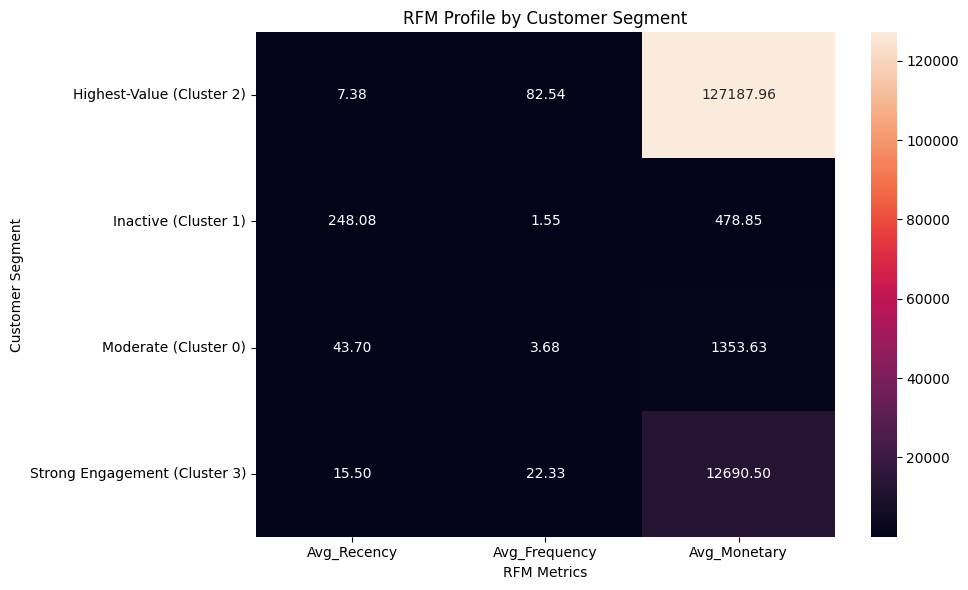

In [66]:
# RFM Heatmap by Customer Segment

segment_profile = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_profile

# Heatmap of Average RFM Values

heatmap_data = segment_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f"
)

plt.title("RFM Profile by Customer Segment")
plt.xlabel("RFM Metrics")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## Customer Segment Interpretation

The K-Means clustering analysis identified four distinct customer segments based on Recency, Frequency, and Monetary behaviour.

### Champions

Champions are the highest-value customers. They have very recent purchases, extremely high purchase frequency, and exceptionally high monetary value. These customers are highly engaged and contribute significantly to the business revenue.

### Loyal Customers

Loyal Customers show frequent purchasing behaviour with relatively recent transactions and high monetary value. They demonstrate strong engagement with the business and have good potential for long-term retention.

### Regular Customers

Regular Customers represent the largest customer segment. They have moderate recency, lower purchase frequency, and moderate monetary value. This segment provides a significant opportunity to increase engagement and purchase frequency.

### At-Risk Customers

At-Risk Customers have high recency values, low purchase frequency, and low monetary value. Their long period since the last purchase indicates that they may have become inactive and require re-engagement strategies.

## Marketing Recommendations

### Champions
- Provide exclusive loyalty rewards.
- Offer early access to new products.
- Provide personalized premium offers.
- Encourage referrals and loyalty-program participation.

### Loyal Customers
- Provide loyalty points and repeat-purchase rewards.
- Recommend related products based on previous purchases.
- Offer personalized discounts to maintain engagement.

### Regular Customers
- Use promotional campaigns to increase purchase frequency.
- Provide bundle offers and limited-time discounts.
- Recommend products based on previous purchasing behaviour.
- Encourage customers to move toward higher-value purchasing.

### At-Risk Customers
- Launch targeted re-engagement campaigns.
- Provide personalized comeback discounts.
- Send reminders and relevant product recommendations.
- Offer incentives for completing their next purchase.

## Key Business Insights

- The Champions segment contains only a small number of customers but has exceptionally high purchase frequency and monetary value, making this group highly valuable to the business.
- Loyal Customers demonstrate strong purchasing behaviour and represent an important revenue-generating segment.
- Regular Customers form the largest segment, creating a significant opportunity to increase customer engagement and purchase frequency.
- At-Risk Customers have the highest recency and the lowest frequency and monetary values, indicating a need for targeted re-engagement campaigns.
- Customer segmentation allows the business to apply different marketing strategies to different customer groups instead of using a single strategy for all customers.
- RFM-based segmentation helps the business identify high-value customers, regular customers, and customers who may require retention or reactivation strategies.

## Conclusion

Customer segmentation was performed using RFM analysis and the K-Means clustering algorithm. Customers were grouped according to their recency, purchase frequency, and monetary value.

The analysis identified four meaningful customer segments: Champions, Loyal Customers, Regular Customers, and At-Risk Customers.

The Champions segment represents highly valuable customers who can be retained through exclusive rewards and personalized offers. Loyal Customers can be encouraged to maintain their purchasing behaviour through loyalty programs and personalized recommendations. Regular Customers provide an opportunity to increase purchase frequency through promotional campaigns and product recommendations. At-Risk Customers can be targeted using re-engagement campaigns and personalized incentives.

Overall, the analysis demonstrates how customer transaction data can be transformed into meaningful behavioural segments that support targeted marketing strategies and data-driven business decisions.